# Opening and exploring a SWOT PIXC product

This training notebook introduces the structure of a **SWOT Level-2 High-Rate PIXC (Pixel Cloud)** product and demonstrates several simple visualization workflows.

The exercises show how to:

1. Open the `pixel_cloud` group of a PIXC NetCDF file.
2. Inspect available variables and dimensions.
3. Compute a corrected water-surface elevation quantity from PIXC height and geophysical corrections.
4. Export selected pixel attributes to a vector file.
5. Visualize PIXC classification classes.
6. Compare open-water and dark-water pixels.
7. Plot corrected water-surface elevation for a large random pixel sample.

> **Training note:** PIXC files can contain millions of pixels. Several plots therefore use random sampling to keep memory use and plotting time reasonable.


## 1. Import libraries and define course directories

All paths are built from:

```python
Path.home() / "swot_course"
```

This makes the notebook portable across Windows, Linux, and macOS.

The PIXC file downloaded in the previous exercise is expected inside:

```text
~/swot_course/pixc
```

The output vector file is stored inside:

```text
~/swot_course/outputs/pixc
```


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr


# ============================================================
# USER CONFIGURATION
# ============================================================

# General directory used by the SWOT training course.
COURSE_DIR = Path.home() / "course/swot_data"


# Directory containing downloaded PIXC files.
PIXC_DIR = (
    COURSE_DIR
    / "pixc"
)


# Directory used for outputs generated by this notebook.
OUTPUT_DIR = Path.home() / "outputs_swot_course"


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# PIXC file used in this exercise.
#
# Change only the filename when another PIXC granule is analyzed.
PIXC_FILE = (
    PIXC_DIR
    / "SWOT_L2_HR_PIXC_050_549_179R_20260528T044523_20260528T044534_PID0_01.nc"
)


# Output vector file.
#
# GeoPackage is used instead of ESRI Shapefile because it preserves
# long attribute names and modern data types more reliably.
OUTPUT_GPKG = (
    OUTPUT_DIR
    / "PIXC_points.gpkg"
)


# Random seed used by all sampling exercises.
# Keeping the same seed makes classroom results reproducible.
RANDOM_SEED = 42


print("PIXC input file:")
print(PIXC_FILE)

print()

print("Output directory:")
print(OUTPUT_DIR)


PIXC input file:
/home/moreira/swot_course/pixc/SWOT_L2_HR_PIXC_050_549_179R_20260528T044523_20260528T044534_PID0_01.nc

Output directory:
/home/moreira/swot_course/outputs/pixc


## 2. Open the PIXC `pixel_cloud` group

A SWOT PIXC NetCDF file contains several groups. The pixel-level observations used in this notebook are stored in the `pixel_cloud` group.

`xarray.open_dataset()` opens this group without immediately converting the complete dataset to a pandas table, which helps avoid unnecessary memory use.


In [6]:
# ============================================================
# CHECK THAT THE INPUT FILE EXISTS
# ============================================================

if not PIXC_FILE.exists():

    available_files = sorted(
        PIXC_DIR.glob("SWOT_L2_HR_PIXC_*.nc")
    )

    message = (
        f"PIXC file not found:\n{PIXC_FILE}\n"
    )

    if available_files:

        message += (
            "\nAvailable PIXC files in the directory:\n"
            + "\n".join(
                str(path.name)
                for path in available_files[:20]
            )
        )

    raise FileNotFoundError(
        message
    )


# ============================================================
# OPEN THE PIXEL_CLOUD GROUP
# ============================================================

ds_PIXC = xr.open_dataset(
    PIXC_FILE,
    group="pixel_cloud",
    engine="netcdf4",
    chunks=None
)


# ============================================================
# BASIC DATASET INFORMATION
# ============================================================

print("Dataset dimensions:")
print(ds_PIXC.sizes)

print()

print("Number of data variables:")
print(len(ds_PIXC.data_vars))

print()

print("Available variables:")
print(list(ds_PIXC.data_vars))


Dataset dimensions:
Frozen({'points': 3830081, 'complex_depth': 2, 'num_pixc_lines': 3280})

Number of data variables:
62

Available variables:
['azimuth_index', 'range_index', 'interferogram', 'power_plus_y', 'power_minus_y', 'coherent_power', 'x_factor_plus_y', 'x_factor_minus_y', 'water_frac', 'water_frac_uncert', 'classification', 'false_detection_rate', 'missed_detection_rate', 'prior_water_prob', 'prior_water_change', 'bright_land_flag', 'layover_impact', 'eff_num_rare_looks', 'height', 'cross_track', 'pixel_area', 'inc', 'phase_noise_std', 'dlatitude_dphase', 'dlongitude_dphase', 'dheight_dphase', 'dheight_droll', 'dheight_dbaseline', 'dheight_drange', 'darea_dheight', 'illumination_time', 'illumination_time_tai', 'eff_num_medium_looks', 'sig0', 'sig0_uncert', 'phase_unwrapping_region', 'ambiguity_cost1', 'ambiguity_cost2', 'instrument_range_cor', 'instrument_phase_cor', 'instrument_baseline_cor', 'sig0_cor_atmos_model', 'height_cor_xover', 'model_dry_tropo_cor', 'model_wet_trop

## 3. Compute corrected water-surface elevation

For this exercise, a corrected elevation quantity is calculated from the PIXC `height` variable by subtracting the geoid and selected geophysical tide corrections:

```text
corrected WSE =
    height
    - geoid
    - solid_earth_tide
    - load_tide_fes
    - pole_tide
```

The resulting `xarray.DataArray` is kept lazy until its values are explicitly requested.


In [13]:
# ============================================================
# COMPUTE CORRECTED WATER-SURFACE ELEVATION
# ============================================================

corrected_wse = (
    ds_PIXC["height"]
    - ds_PIXC["geoid"]
    - ds_PIXC["solid_earth_tide"]
    - ds_PIXC["load_tide_fes"]
    - ds_PIXC["pole_tide"]
)


# The main PIXC point dimension is obtained directly from
# the classification variable. This is more robust than relying
# on the first entry returned by ds_PIXC.dims.
point_dim = (
    ds_PIXC["classification"]
    .dims[0]
)

n_points = (
    ds_PIXC.sizes[
        point_dim
    ]
)


print(
    f"Main pixel dimension: {point_dim}"
)

print(
    f"Total PIXC points: {n_points:,}"
)


Main pixel dimension: points
Total PIXC points: 3,830,081


## 4. Export selected PIXC attributes as a vector layer

This optional exercise converts selected PIXC pixels to point geometries.

Because a complete PIXC granule may contain millions of pixels, exporting every point can require substantial memory and disk space. The parameter `MAX_VECTOR_POINTS` controls how many pixels are exported:

- `None` → export all PIXC pixels;
- an integer such as `250_000` → export a reproducible random sample.

For a training session, a sample is usually sufficient and much faster.


In [12]:
# ============================================================
# VECTOR EXPORT CONFIGURATION
# ============================================================

# Maximum number of PIXC points exported to the GeoPackage.
#
# None    -> export all pixels
# 250_000 -> export at most 250,000 randomly selected pixels
MAX_VECTOR_POINTS = 250_000


# Attributes included in the vector output.
selected_variables = [
    "water_frac",
    "sig0",
    "height",
    "longitude",
    "latitude",
    "classification",
]


# ============================================================
# SELECT PIXELS FOR EXPORT
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)


if (
    MAX_VECTOR_POINTS is None
    or n_points <= MAX_VECTOR_POINTS
):

    export_indices = np.arange(
        n_points
    )

else:

    export_indices = rng.choice(
        n_points,
        size=MAX_VECTOR_POINTS,
        replace=False
    )

    export_indices = np.sort(
        export_indices
    )


print(
    f"Pixels selected for vector export: "
    f"{len(export_indices):,}"
)


# ============================================================
# READ ONLY THE SELECTED PIXELS
# ============================================================

sample_for_export = ds_PIXC[
    selected_variables
].isel({
    point_dim: export_indices
})


df_export = (
    sample_for_export
    .to_dataframe()
    .reset_index()
)


# Add corrected WSE using the same selected pixel indices.
df_export[
    "corrected_wse"
] = (
    corrected_wse
    .isel({
        point_dim: export_indices
    })
    .values
)


# ============================================================
# CREATE POINT GEOMETRIES
# ============================================================

valid_coordinates = (
    np.isfinite(
        df_export["longitude"]
    )
    & np.isfinite(
        df_export["latitude"]
    )
)


df_export = df_export[
    valid_coordinates
].copy()


gdf_export = gpd.GeoDataFrame(
    df_export,
    geometry=gpd.points_from_xy(
        df_export["longitude"],
        df_export["latitude"]
    ),
    crs="EPSG:4326"
)


# ============================================================
# SAVE THE VECTOR FILE
# ============================================================

gdf_export.to_file(
    OUTPUT_GPKG,
    driver="GPKG"
)


print(
    f"Vector file saved to: {OUTPUT_GPKG}"
)

print(
    f"Exported point features: {len(gdf_export):,}"
)


Pixels selected for vector export: 250,000
Vector file saved to: /home/moreira/swot_course/outputs/pixc/PIXC_points.gpkg
Exported point features: 250,000


## 5. Visualize PIXC classification classes

PIXC pixels are assigned classification codes describing land and water-related surface types.

To keep the figure responsive, only a random fraction of the PIXC points is plotted.

The same random seed is used each time, so students obtain reproducible figures.


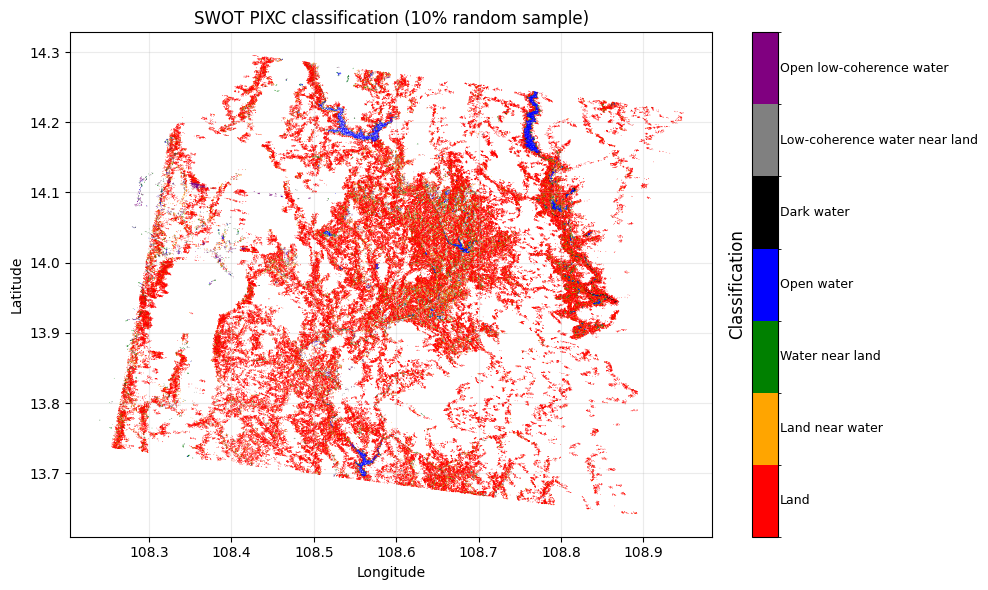

In [8]:
# ============================================================
# CLASSIFICATION PLOT CONFIGURATION
# ============================================================

SAMPLE_FRACTION = 0.10


sample_size = max(
    1,
    int(
        SAMPLE_FRACTION
        * n_points
    )
)


rng = np.random.default_rng(
    RANDOM_SEED
)


sample_indices = rng.choice(
    n_points,
    size=sample_size,
    replace=False
)


sample_indices = np.sort(
    sample_indices
)


# ============================================================
# READ THE SAMPLED VARIABLES
# ============================================================

sampled_data = ds_PIXC.isel({
    point_dim: sample_indices
})


lon = (
    sampled_data["longitude"]
    .values
)

lat = (
    sampled_data["latitude"]
    .values
)

classification = (
    sampled_data["classification"]
    .values
)


# Remove pixels with invalid coordinates or classification.
valid = (
    np.isfinite(lon)
    & np.isfinite(lat)
    & np.isfinite(classification)
)


lon = lon[
    valid
]

lat = lat[
    valid
]

classification = classification[
    valid
]


# ============================================================
# CLASSIFICATION LABELS
# ============================================================

class_labels = {
    1: "Land",
    2: "Land near water",
    3: "Water near land",
    4: "Open water",
    5: "Dark water",
    6: "Low-coherence water near land",
    7: "Open low-coherence water",
}


manual_colors = {
    1: "red",
    2: "orange",
    3: "green",
    4: "blue",
    5: "black",
    6: "gray",
    7: "purple",
}


unique_classes = np.array(
    sorted(
        class_labels.keys()
    )
)


color_list = [
    manual_colors[class_id]
    for class_id in unique_classes
]


cmap = mcolors.ListedColormap(
    color_list
)


boundaries = np.append(
    unique_classes,
    unique_classes[-1] + 1
)


norm = mcolors.BoundaryNorm(
    boundaries=boundaries,
    ncolors=len(unique_classes)
)


# ============================================================
# CREATE THE CLASSIFICATION FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


scatter = ax.scatter(
    lon,
    lat,
    s=0.2,
    c=classification,
    cmap=cmap,
    norm=norm,
    linewidths=0
)


cbar = fig.colorbar(
    scatter,
    ax=ax,
    boundaries=boundaries,
    spacing="proportional"
)


# Hide numeric ticks because descriptive class names are shown instead.
cbar.set_ticks([])


cbar.ax.text(
    -0.6,
    0.5,
    "Classification",
    rotation=90,
    ha="center",
    va="center",
    fontsize=12,
    transform=cbar.ax.transAxes
)


# Add the descriptive label beside each classification band.
for i, class_id in enumerate(
    unique_classes
):

    center = (
        boundaries[i]
        + boundaries[i + 1]
    ) / 2


    cbar.ax.text(
        1.1,
        center,
        class_labels[class_id],
        ha="left",
        va="center",
        fontsize=9,
        transform=cbar.ax.transData
    )


ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    "SWOT PIXC classification "
    f"({SAMPLE_FRACTION:.0%} random sample)"
)

ax.grid(
    True,
    alpha=0.25
)


fig.tight_layout()

plt.show()


## 6. Compare open-water and dark-water pixels using PIXC height

This figure uses a maximum random sample of one million PIXC pixels.

The sample is created **before filtering by classification**, which avoids loading the complete granule into memory.

For this exercise:

- class `4` = open water;
- class `5` = dark water.

Open-water pixels are colored by the original PIXC `height` variable, while dark-water pixels are displayed with a single marker color.


Open-water pixels in sample: 25,738
Dark-water pixels in sample: 1,518


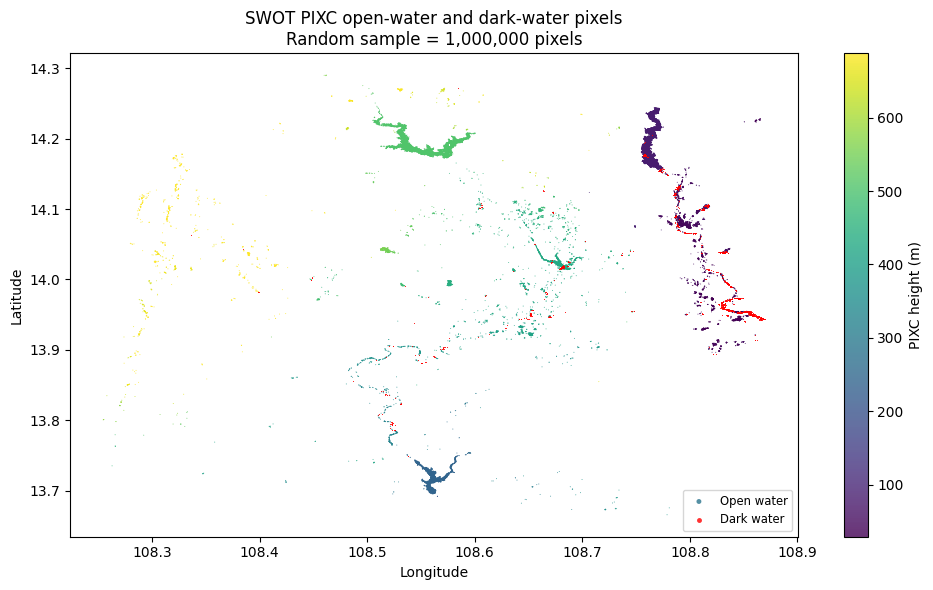

In [9]:
# ============================================================
# CONFIGURATION
# ============================================================

N_SAMPLE = 1_000_000


rng = np.random.default_rng(
    RANDOM_SEED
)


n_use = min(
    N_SAMPLE,
    n_points
)


sample_indices = rng.choice(
    n_points,
    size=n_use,
    replace=False
)


sample_indices = np.sort(
    sample_indices
)


# ============================================================
# READ ONLY THE VARIABLES NEEDED FOR THE SAMPLE
# ============================================================

classification = (
    ds_PIXC["classification"]
    .isel({
        point_dim: sample_indices
    })
    .values
)


lon = (
    ds_PIXC["longitude"]
    .isel({
        point_dim: sample_indices
    })
    .values
)


lat = (
    ds_PIXC["latitude"]
    .isel({
        point_dim: sample_indices
    })
    .values
)


height = (
    ds_PIXC["height"]
    .isel({
        point_dim: sample_indices
    })
    .values
)


# ============================================================
# FILTER CLASSES 4 AND 5
# ============================================================

mask4 = (
    classification == 4
)

mask5 = (
    classification == 5
)


lon4 = lon[
    mask4
]

lat4 = lat[
    mask4
]

height4 = height[
    mask4
]


lon5 = lon[
    mask5
]

lat5 = lat[
    mask5
]


valid4 = (
    np.isfinite(lon4)
    & np.isfinite(lat4)
    & np.isfinite(height4)
)


valid5 = (
    np.isfinite(lon5)
    & np.isfinite(lat5)
)


lon4 = lon4[
    valid4
]

lat4 = lat4[
    valid4
]

height4 = height4[
    valid4
]


lon5 = lon5[
    valid5
]

lat5 = lat5[
    valid5
]


print(
    f"Open-water pixels in sample: {len(lon4):,}"
)

print(
    f"Dark-water pixels in sample: {len(lon5):,}"
)


# ============================================================
# COLOR SCALE
# ============================================================

if len(height4) == 0:

    raise ValueError(
        "No valid class-4 pixels were found in the sample."
    )


vmin = np.nanpercentile(
    height4,
    2.5
)

vmax = np.nanpercentile(
    height4,
    97.5
)


# ============================================================
# CREATE THE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


sc = ax.scatter(
    lon4,
    lat4,
    s=0.5,
    c=height4,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    linewidths=0,
    alpha=0.8,
    label="Open water"
)


ax.scatter(
    lon5,
    lat5,
    s=0.5,
    color="red",
    linewidths=0,
    alpha=0.8,
    label="Dark water"
)


cbar = fig.colorbar(
    sc,
    ax=ax
)

cbar.set_label(
    "PIXC height (m)"
)


ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    "SWOT PIXC open-water and dark-water pixels\n"
    f"Random sample = {n_use:,} pixels"
)


ax.legend(
    loc="lower right",
    markerscale=5,
    fontsize="small"
)


fig.tight_layout()

plt.show()


## 7. Compare open-water and dark-water pixels using corrected WSE

This exercise repeats the previous comparison but colors open-water pixels using the corrected WSE quantity calculated earlier.

Sampling is again performed before the PIXC arrays are loaded, keeping the workflow suitable for large granules.


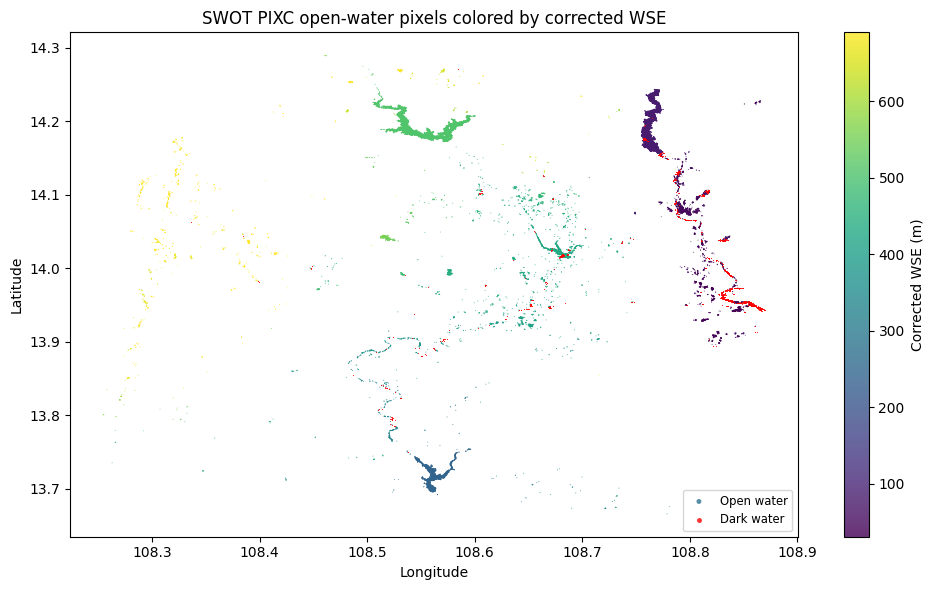

In [10]:
# ============================================================
# READ CORRECTED WSE FOR THE SAME SAMPLE
# ============================================================

wse_sample = (
    corrected_wse
    .isel({
        point_dim: sample_indices
    })
    .values
)


wse4 = wse_sample[
    mask4
]


# Remove invalid values.
valid4_wse = (
    np.isfinite(lon4)
    & np.isfinite(lat4)
)


# lon4 and lat4 were already filtered above.
# Apply an independent validity mask to WSE itself.
valid_wse_values = np.isfinite(
    wse4[
        valid4
    ]
)


plot_lon4 = lon4[
    valid_wse_values
]

plot_lat4 = lat4[
    valid_wse_values
]

plot_wse4 = (
    wse4[
        valid4
    ][
        valid_wse_values
    ]
)


if len(plot_wse4) == 0:

    raise ValueError(
        "No valid corrected-WSE values were found for class 4."
    )


# Use central percentiles so that extreme values do not dominate
# the color scale.
vmin = np.nanpercentile(
    plot_wse4,
    2.5
)

vmax = np.nanpercentile(
    plot_wse4,
    97.5
)


# ============================================================
# CREATE THE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


sc = ax.scatter(
    plot_lon4,
    plot_lat4,
    s=0.5,
    c=plot_wse4,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    linewidths=0,
    alpha=0.8,
    label="Open water"
)


ax.scatter(
    lon5,
    lat5,
    s=0.5,
    color="red",
    linewidths=0,
    alpha=0.8,
    label="Dark water"
)


cbar = fig.colorbar(
    sc,
    ax=ax
)

cbar.set_label(
    "Corrected WSE (m)"
)


ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    "SWOT PIXC open-water pixels colored by corrected WSE"
)


ax.legend(
    loc="lower right",
    markerscale=5,
    fontsize="small"
)


fig.tight_layout()

plt.show()


## 8. Plot corrected WSE for all PIXC classes

The final exercise colors the complete random sample by corrected WSE, without filtering by classification.

The 2.5th and 97.5th percentiles are used as plotting limits so that a small number of extreme values do not dominate the color scale.


Pixels used in the figure: 1,000,000
Corrected WSE p2.5: 36.798 m
Corrected WSE p97.5: 847.700 m


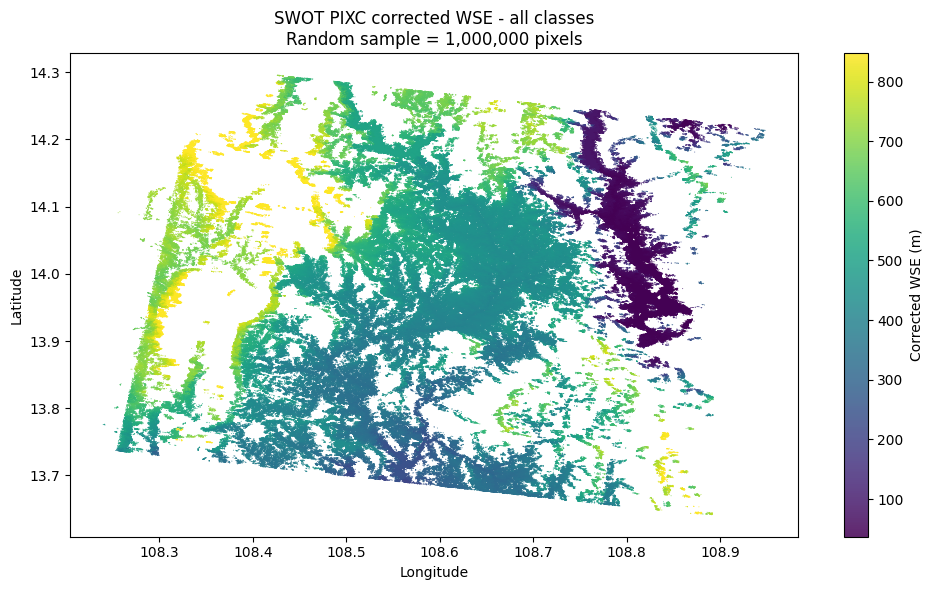

In [11]:
# ============================================================
# READ VARIABLES FOR THE SAMPLE
# ============================================================

lon_all = (
    ds_PIXC["longitude"]
    .isel({
        point_dim: sample_indices
    })
    .values
)


lat_all = (
    ds_PIXC["latitude"]
    .isel({
        point_dim: sample_indices
    })
    .values
)


wse_all = (
    corrected_wse
    .isel({
        point_dim: sample_indices
    })
    .values
)


classification_all = (
    ds_PIXC["classification"]
    .isel({
        point_dim: sample_indices
    })
    .values
)


# ============================================================
# REMOVE INVALID VALUES
# ============================================================

valid = (
    np.isfinite(lon_all)
    & np.isfinite(lat_all)
    & np.isfinite(wse_all)
)


lon_all = lon_all[
    valid
]

lat_all = lat_all[
    valid
]

wse_all = wse_all[
    valid
]

classification_all = classification_all[
    valid
]


print(
    f"Pixels used in the figure: {len(wse_all):,}"
)


# ============================================================
# COLOR SCALE
# ============================================================

if len(wse_all) == 0:

    raise ValueError(
        "No valid corrected-WSE pixels were found in the sample."
    )


vmin = np.nanpercentile(
    wse_all,
    2.5
)

vmax = np.nanpercentile(
    wse_all,
    97.5
)


print(
    f"Corrected WSE p2.5: {vmin:.3f} m"
)

print(
    f"Corrected WSE p97.5: {vmax:.3f} m"
)


# ============================================================
# CREATE THE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


sc = ax.scatter(
    lon_all,
    lat_all,
    s=0.5,
    c=wse_all,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    linewidths=0,
    alpha=0.85
)


cbar = fig.colorbar(
    sc,
    ax=ax
)

cbar.set_label(
    "Corrected WSE (m)"
)


ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)


ax.set_title(
    "SWOT PIXC corrected WSE - all classes\n"
    f"Random sample = {len(wse_all):,} pixels"
)


fig.tight_layout()

plt.show()


## 9. Close the PIXC dataset

Closing the xarray dataset releases the open NetCDF/HDF5 file handle after the exercises are complete.


In [ ]:
ds_PIXC.close()

print(
    "PIXC dataset closed."
)
